
---> Avvio calcoli per N = 32 <---
Genero i plot grafici per N = 32...


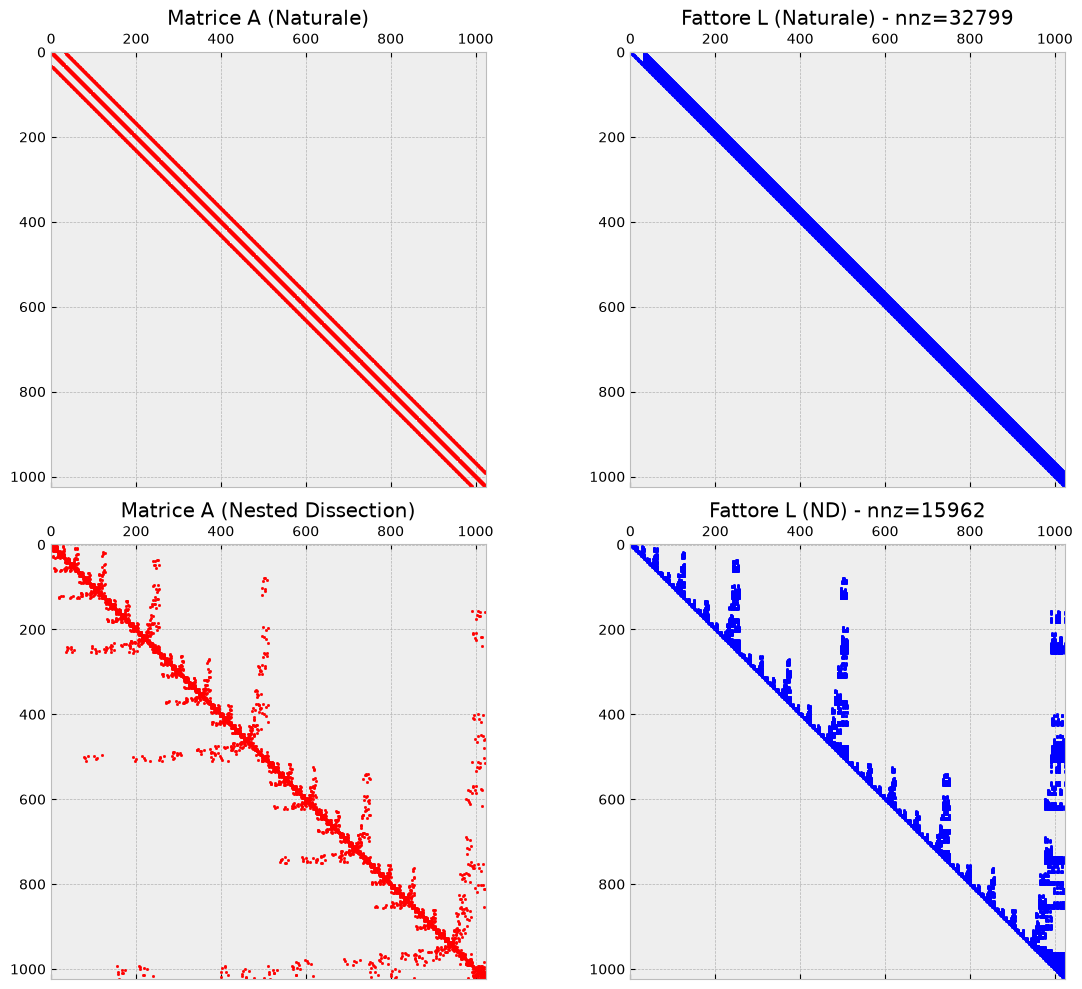

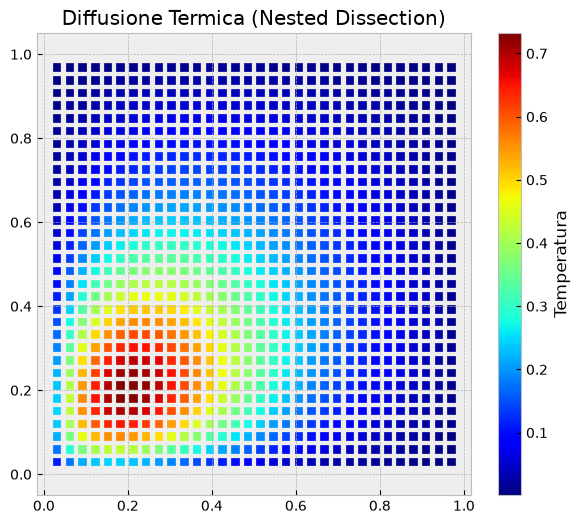


---> Avvio calcoli per N = 64 <---

---> Avvio calcoli per N = 128 <---

---> Avvio calcoli per N = 256 <---

---> Avvio calcoli per N = 512 <---

---> Avvio calcoli per N = 1024 <---

Elaborazione completata. Generazione dei grafici di confronto...


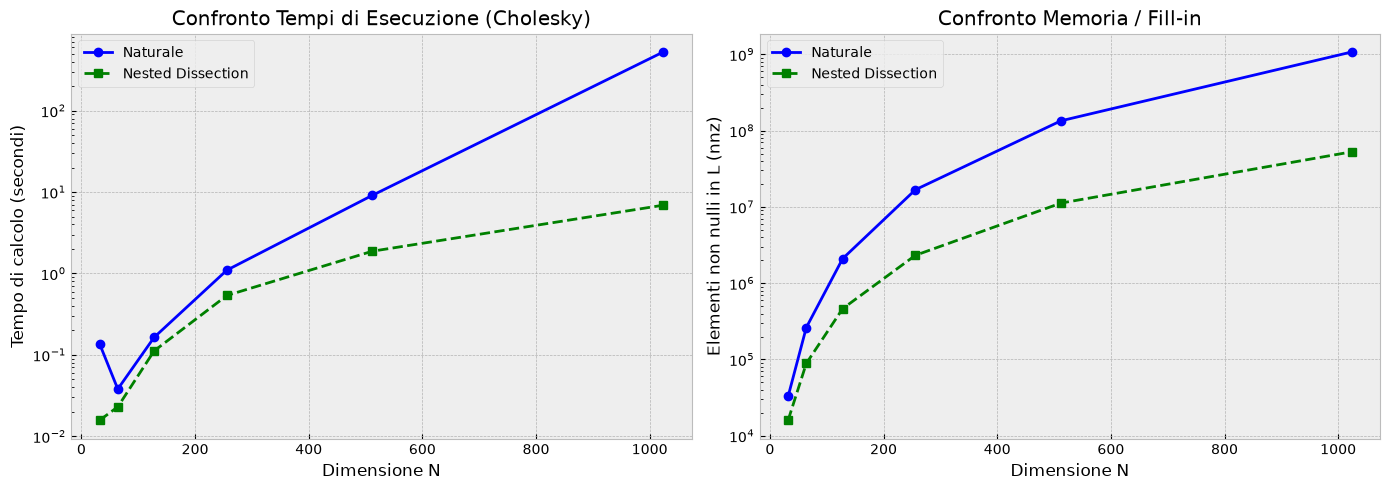

In [4]:
import numpy as np
import scipy.sparse as sp
from sksparse.cholmod import cho_factor
import matplotlib.pyplot as plt
import time
import os

plt.style.use('bmh')
os.chdir(r"C:\Users\jacop\Desktop\Progetto-informatica")
# =============================================================================
# 1. FUNZIONI DI SUPPORTO (Dal tuo Task 4)
# =============================================================================
def load_ordering_file(path, coords):
    ordering = np.loadtxt(path, dtype=int)
    m = ordering[:, 0]
    n = ordering[:, 1]
    order_map = np.empty(len(m), dtype=int)
    order_map[m] = n
    idx_coords = coords[:, 0].astype(int)
    pos_of_n = np.empty(idx_coords.max() + 1, dtype=int)
    pos_of_n[idx_coords] = np.arange(len(idx_coords))
    riga_naturale = pos_of_n[order_map]
    x_new = coords[riga_naturale, 3]
    y_new = coords[riga_naturale, 4]
    return x_new, y_new

# =============================================================================
# 2. INIZIALIZZAZIONE VARIABILI
# =============================================================================
N_values = [32, 64, 128, 256, 512, 1024]

tempi_nat = []
tempi_nd = []
nnz_nat = []
nnz_nd = []

# =============================================================================
# 3. CICLO SU TUTTI GLI N
# =============================================================================
for N in N_values:
    print(f"\n---> Avvio calcoli per N = {N} <---")
    
    # Calcolo quanti nodi ci sono nel sistema.
    # NOTA: Adatta questa riga se la formula dei nodi è diversa! 
    # Spesso è (N-1)*(N-1) per le differenze finite interne.
    N_nodi = N * N 
    
    # Carichiamo le coordinate comuni a questo N dalla cartella "dati"
    coords = np.loadtxt(f'dati/coords_{N}.txt')

    # ---------------------------------------------------
    # BLOCCO A: Ordinamento Naturale
    # ---------------------------------------------------
    A_data_nat = np.loadtxt(f'dati/A_nat_{N}.txt')
    rhs_nat = np.loadtxt(f'dati/rhs_nat_{N}.txt')
    
    # Costruzione matrice sparsa
    A_csc_nat = sp.csc_matrix((A_data_nat[:, 2], 
                               (A_data_nat[:, 0].astype(int), A_data_nat[:, 1].astype(int))), 
                               shape=(N_nodi, N_nodi))
    
    # Cronometriamo Cholesky e salviamo fill-in (nnz)
    start_nat = time.time()
    fattore_nat = cho_factor(A_csc_nat, order="natural")
    u_nat = fattore_nat.solve(rhs_nat)
    end_nat = time.time()
    
    L_mat_nat = sp.csc_matrix(fattore_nat.get_factor())
    
    tempi_nat.append(end_nat - start_nat)
    nnz_nat.append(L_mat_nat.nnz)

    # ---------------------------------------------------
    # BLOCCO B: Ordinamento Nested Dissection (ND)
    # ---------------------------------------------------
    A_data_nd = np.loadtxt(f'dati/A_nd_{N}.txt')
    rhs_nd = np.loadtxt(f'dati/rhs_nd_{N}.txt')
    
    # Costruzione matrice sparsa
    A_csc_nd = sp.csc_matrix((A_data_nd[:, 2], 
                              (A_data_nd[:, 0].astype(int), A_data_nd[:, 1].astype(int))), 
                              shape=(N_nodi, N_nodi))
    
    # Cronometriamo Cholesky e salviamo fill-in (nnz)
    start_nd = time.time()
    fattore_nd = cho_factor(A_csc_nd, order="natural")
    u_nd = fattore_nd.solve(rhs_nd)
    end_nd = time.time()
    
    L_mat_nd = sp.csc_matrix(fattore_nd.get_factor())
    
    tempi_nd.append(end_nd - start_nd)
    nnz_nd.append(L_mat_nd.nnz)

    # ---------------------------------------------------
    # BLOCCO C: Visualizzazione SOLO per griglia piccola
    # ---------------------------------------------------
    if N == 32:
        print("Genero i plot grafici per N = 32...")
        
        # 1. Confronto Sparsità (Spy)
        fig, ax = plt.subplots(2, 2, figsize=(12, 10))
        ax[0, 0].spy(A_csc_nat, markersize=1, color='red')
        ax[0, 0].set_title("Matrice A (Naturale)")
        ax[0, 1].spy(L_mat_nat, markersize=1, color='blue')
        ax[0, 1].set_title(f"Fattore L (Naturale) - nnz={L_mat_nat.nnz}")
        
        ax[1, 0].spy(A_csc_nd, markersize=1, color='red')
        ax[1, 0].set_title("Matrice A (Nested Dissection)")
        ax[1, 1].spy(L_mat_nd, markersize=1, color='blue')
        ax[1, 1].set_title(f"Fattore L (ND) - nnz={L_mat_nd.nnz}")
        
        plt.tight_layout()
        plt.show()

        # 2. Heatmap Soluzione ND (Sfruttando il codice del Task 4)
        x_nd, y_nd = load_ordering_file(f'dati/ordering_{N}.txt', coords)
        
        plt.figure(figsize=(7, 6))
        grafico = plt.scatter(x_nd, y_nd, c=u_nd, cmap='jet', s=30, marker='s')
        plt.colorbar(grafico, label="Temperatura")
        plt.title("Diffusione Termica (Nested Dissection)")
        plt.axis('equal')
        plt.show()

# =============================================================================
# 4. GRAFICI FINALI DI CONFRONTO (Tempi e Memoria per tutti gli N)
# =============================================================================
print("\nElaborazione completata. Generazione dei grafici di confronto...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Grafico Tempi
ax1.plot(N_values, tempi_nat, marker='o', linestyle='-', color='blue', label='Naturale')
ax1.plot(N_values, tempi_nd, marker='s', linestyle='--', color='green', label='Nested Dissection')
ax1.set_xlabel('Dimensione N')
ax1.set_ylabel('Tempo di calcolo (secondi)')
ax1.set_title('Confronto Tempi di Esecuzione (Cholesky)')
ax1.legend()
ax1.grid(True)

# Grafico Fill-in (Memoria)
ax2.plot(N_values, nnz_nat, marker='o', linestyle='-', color='blue', label='Naturale')
ax2.plot(N_values, nnz_nd, marker='s', linestyle='--', color='green', label='Nested Dissection')
ax2.set_xlabel('Dimensione N')
ax2.set_ylabel('Elementi non nulli in L (nnz)')
ax2.set_title('Confronto Memoria / Fill-in')
ax2.legend()
ax2.grid(True)

# Usiamo la scala logaritmica perché le differenze esploderanno per N grandi
ax1.set_yscale('log') 
ax2.set_yscale('log')

plt.tight_layout()
plt.show()